In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
dataset=pd.read_csv("StudentsPerformance.csv")
dataset.head(24)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [4]:
dataset.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
dataset["parental level of education"].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [7]:
dataset["lunch"].unique()

array(['standard', 'free/reduced'], dtype=object)

In [8]:
dataset["test preparation course"].unique()

array(['none', 'completed'], dtype=object)

In [9]:
dataset.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
dataset.duplicated().sum()

np.int64(0)

In [11]:
list_of_columns = [
    'math score', 'reading score',
       'writing score'
]


mean_of_columns = []
variance_of_columns = []
standard_deviation_of_columns=[]
median_of_columns=[]
for col in list_of_columns:
    # Mean
    mean_value = sum(dataset[col]) / len(dataset[col])
    mean_of_columns.append(mean_value)

    # Variance
    diffs = [(x - mean_value)**2 for x in dataset[col]]
    variance_value = sum(diffs) / len(dataset[col])
    variance_of_columns.append(variance_value)

    #Standard deviation
    
    diffs = [(x - mean_value)**2 for x in dataset[col]]
    standard_deviation_value = np.sqrt(sum(diffs) / len(dataset[col]))
    standard_deviation_of_columns.append(standard_deviation_value)

    #median
    col_values=sorted(dataset[col].dropna())
    n=len(col_values)
    if n%2==1:
        median = col_values[n//2]
    else:
        median = (col_values[n//2-1]+col_values[n//2]) / 2
    median_of_columns.append(median)
print("Means:")
print(mean_of_columns)

print("\nVariances:")
print(variance_of_columns)

print("\nStandard deviations:")
print(standard_deviation_of_columns)


print("Medians:")
print( median_of_columns)
                  

Means:
[66.089, 69.169, 68.054]

Variances:
[229.689079, 212.95243900000003, 230.677084]

Standard deviations:
[np.float64(15.155496659628149), np.float64(14.592890015346516), np.float64(15.188057281956768)]
Medians:
[66.0, 70.0, 69.0]


In [12]:
dataset.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [13]:
scores = ['math score','reading score','writing score']
columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course']
for col in columns:
   for score in scores:
    sum_score = dataset.groupby(col)[score].sum()
    len_score = dataset.groupby(col)[score].count()
    mean_score = sum_score / len_score
    
    print(score)
    print(mean_score)
    print()

math score
gender
female    63.633205
male      68.728216
Name: math score, dtype: float64

reading score
gender
female    72.608108
male      65.473029
Name: reading score, dtype: float64

writing score
gender
female    72.467181
male      63.311203
Name: writing score, dtype: float64

math score
race/ethnicity
group A    61.629213
group B    63.452632
group C    64.463950
group D    67.362595
group E    73.821429
Name: math score, dtype: float64

reading score
race/ethnicity
group A    64.674157
group B    67.352632
group C    69.103448
group D    70.030534
group E    73.028571
Name: reading score, dtype: float64

writing score
race/ethnicity
group A    62.674157
group B    65.600000
group C    67.827586
group D    70.145038
group E    71.407143
Name: writing score, dtype: float64

math score
parental level of education
associate's degree    67.882883
bachelor's degree     69.389831
high school           62.137755
master's degree       69.745763
some college          67.128319
some h

In [14]:
scores = ['math score','reading score','writing score']
columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch','test preparation course']
for col in columns:
   for score in scores:
    mean_score = dataset.groupby(col)[score].transform('mean')
    variance_score = ((dataset[score] - mean_score)**2).groupby(dataset[col]).sum() / dataset.groupby(col)[score].count()
    std_score = np.sqrt(variance_score)
    print(score)
    print("Variance")
    print(variance_score)

math score
Variance
gender
female    239.521832
male      205.675096
Name: math score, dtype: float64
reading score
Variance
gender
female    206.334838
male      193.693256
Name: reading score, dtype: float64
writing score
Variance
gender
female    219.943904
male      198.786970
Name: writing score, dtype: float64
math score
Variance
race/ethnicity
group A    208.547911
group B    238.005651
group C    219.910142
group D    188.872341
group E    239.589541
Name: math score, dtype: float64
reading score
Variance
race/ethnicity
group A    238.893827
group B    229.144072
group C    195.302778
group D    192.342579
group E    219.656327
Name: reading score, dtype: float64
writing score
Variance
race/ethnicity
group A    236.579220
group B    242.861053
group C    223.797860
group D    205.643086
group E    226.798520
Name: writing score, dtype: float64
math score
Variance
parental level of education
associate's degree    227.346644
bachelor's degree     221.424303
high school           

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


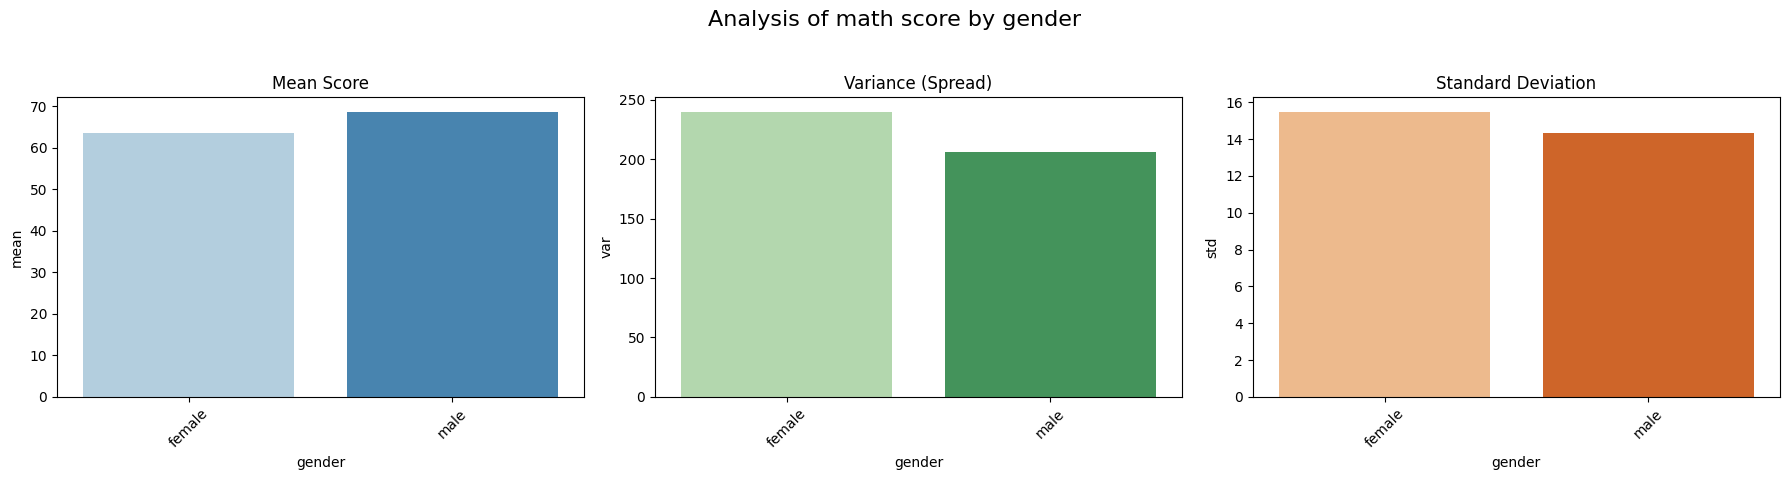

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


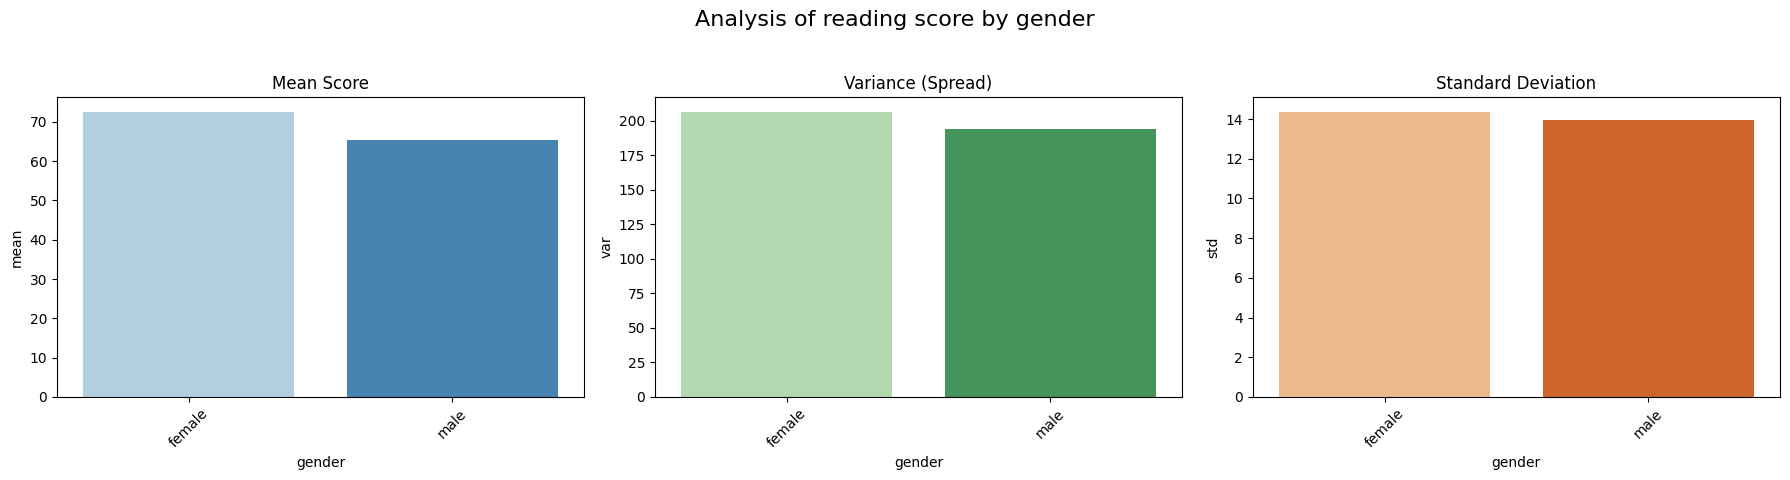

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


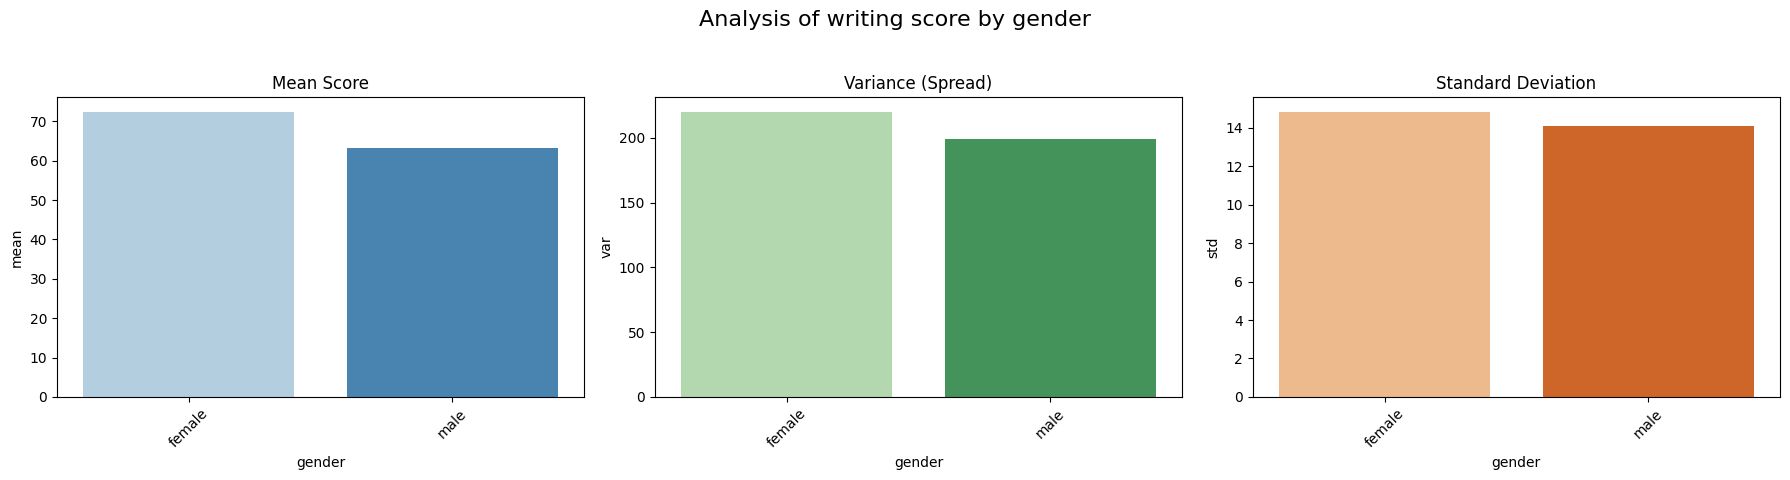

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


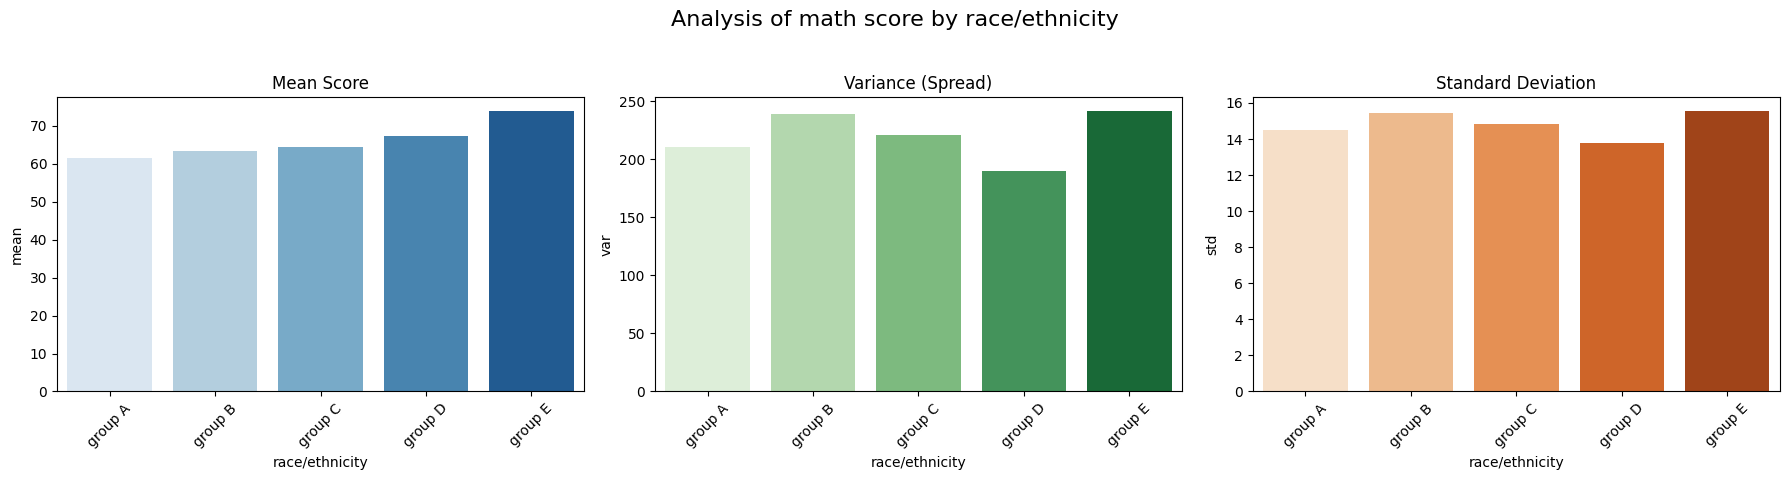

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


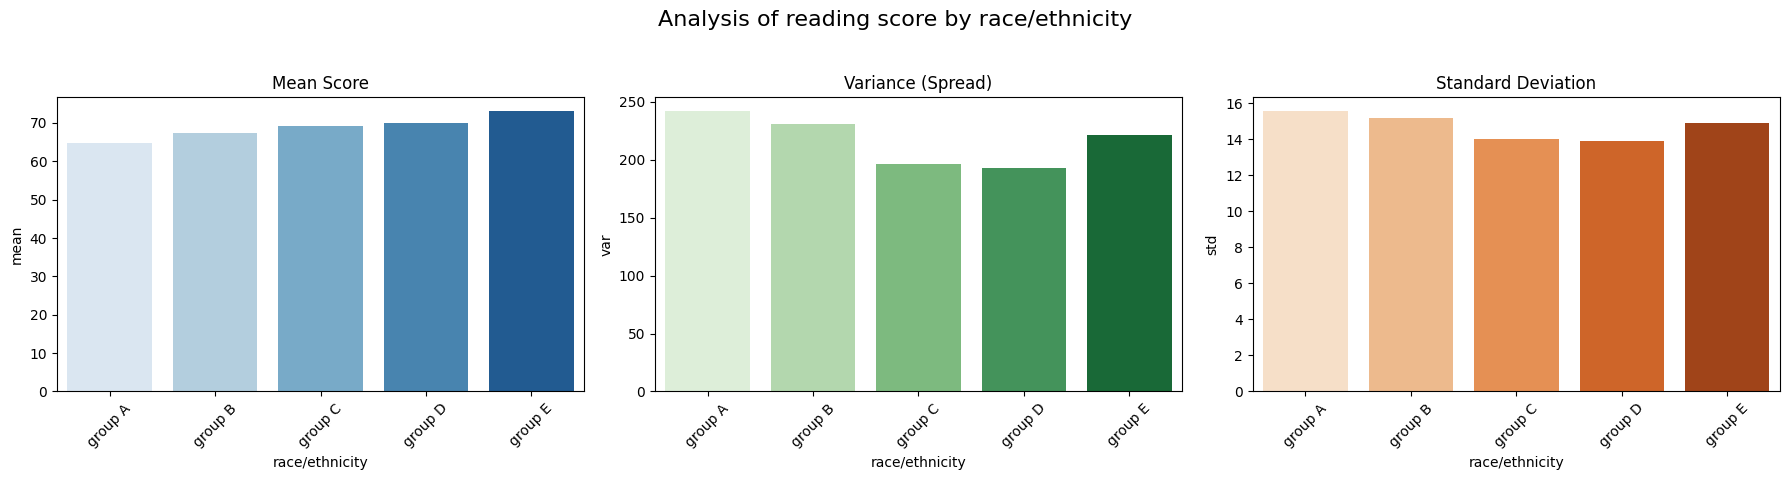

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


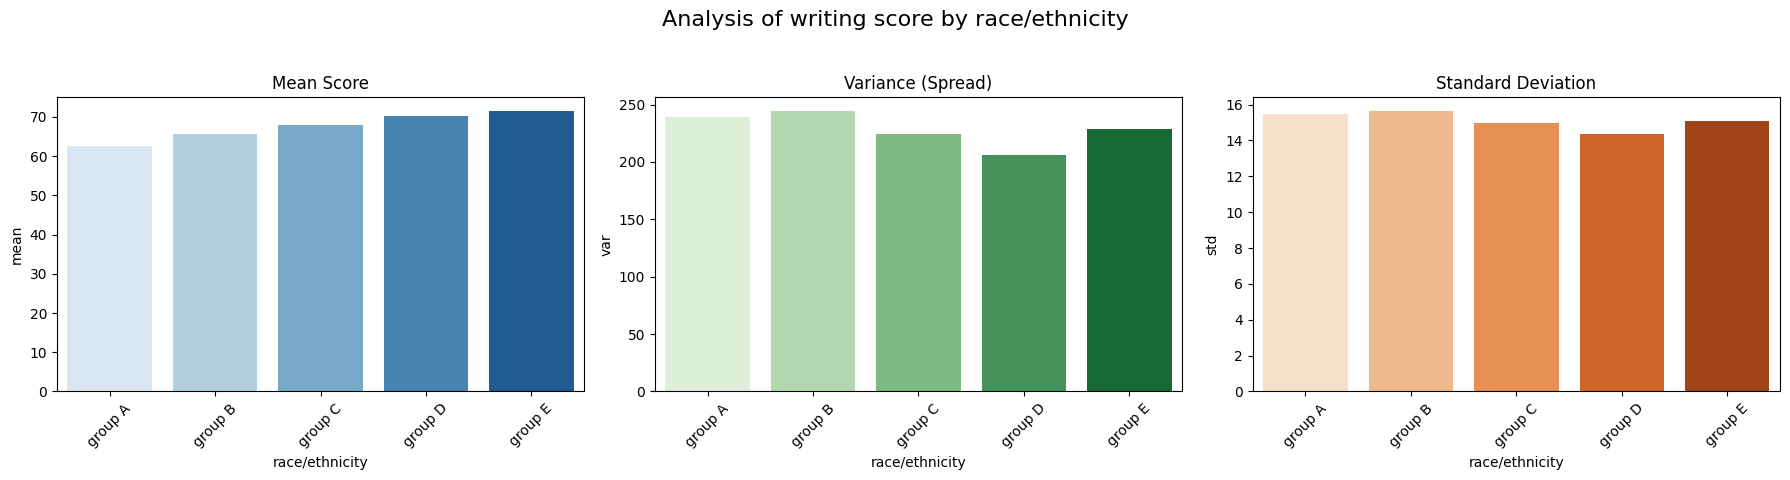

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


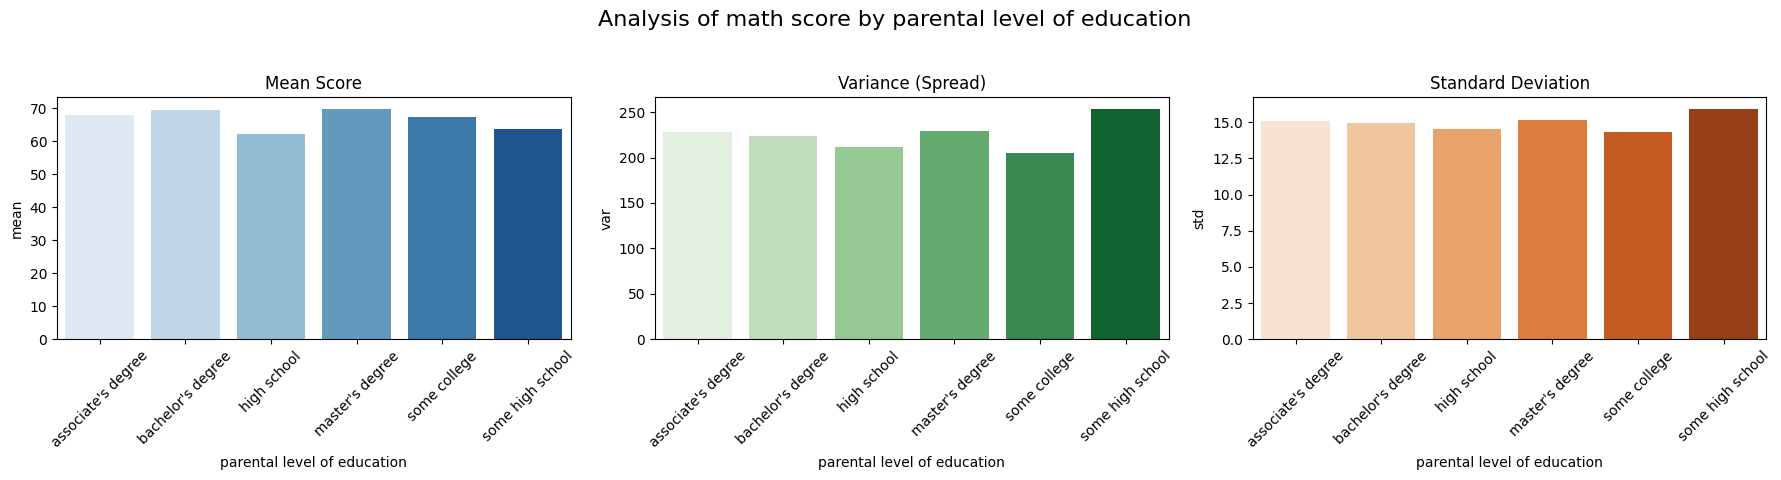

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


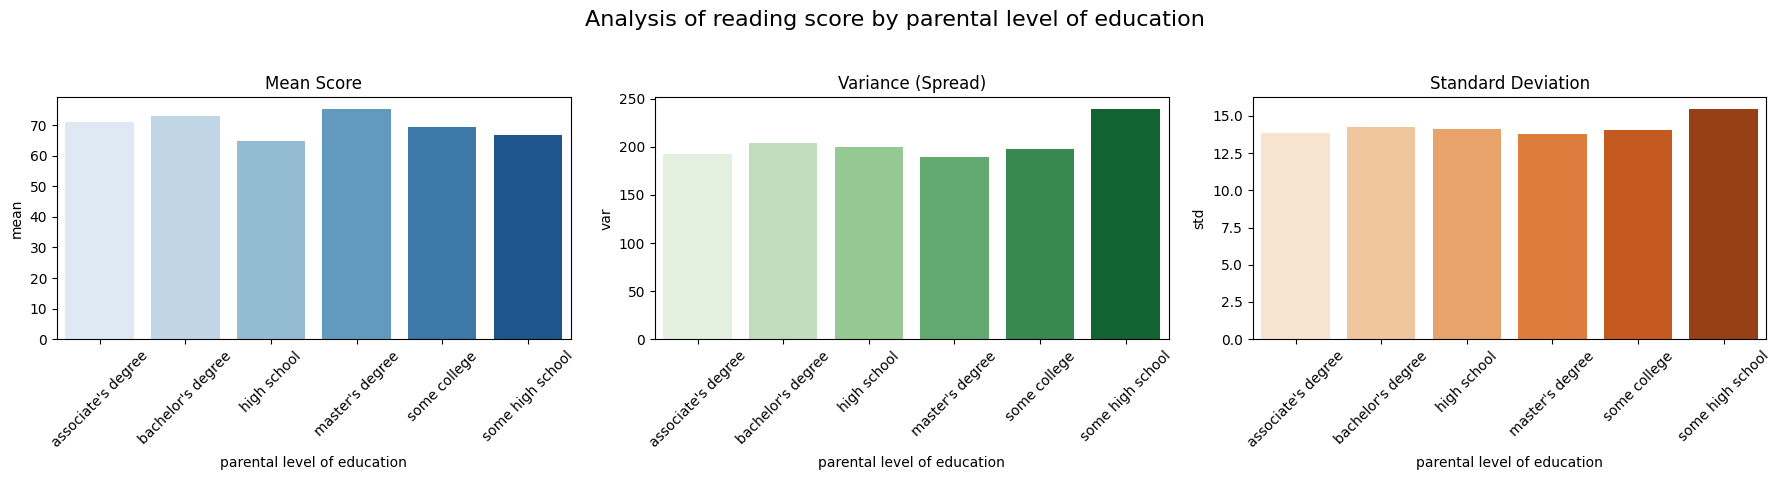

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


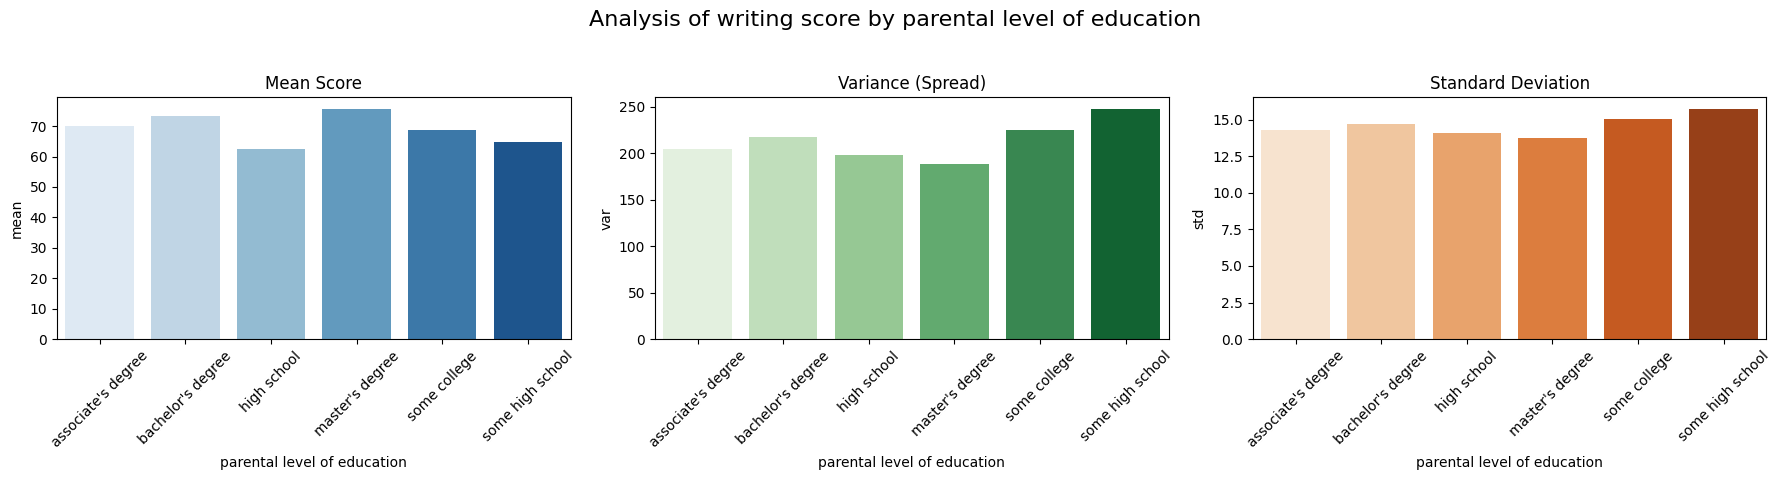

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


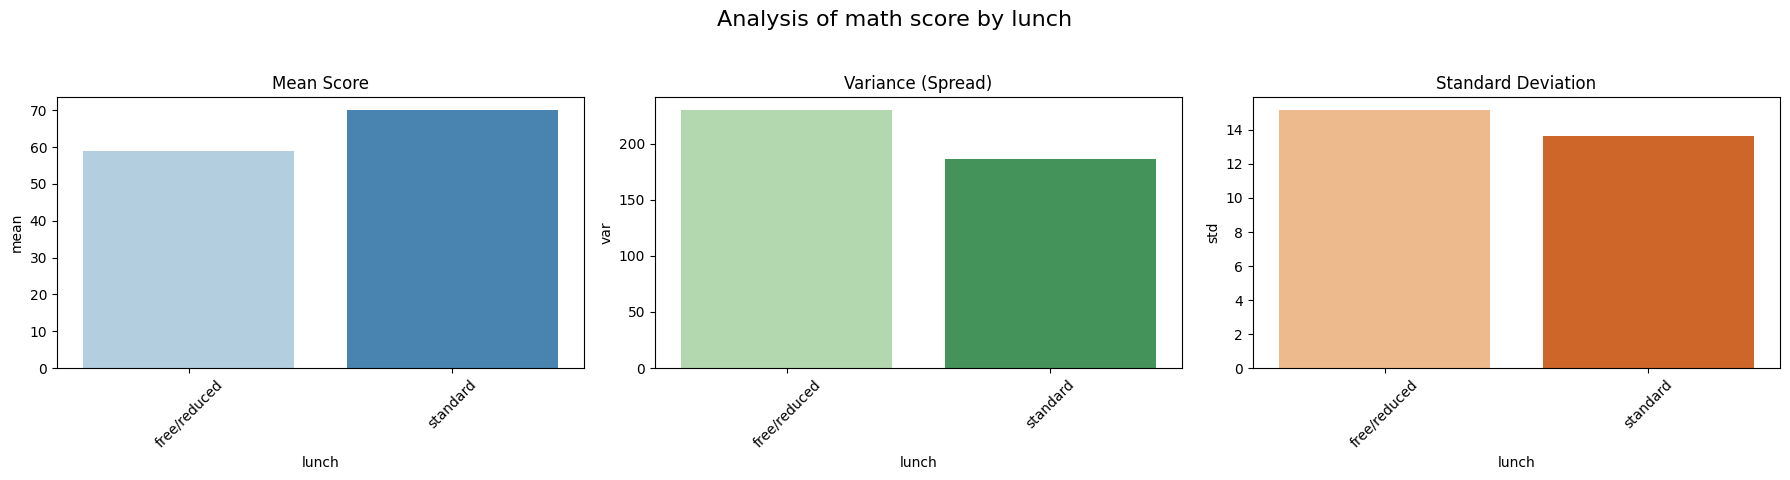

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


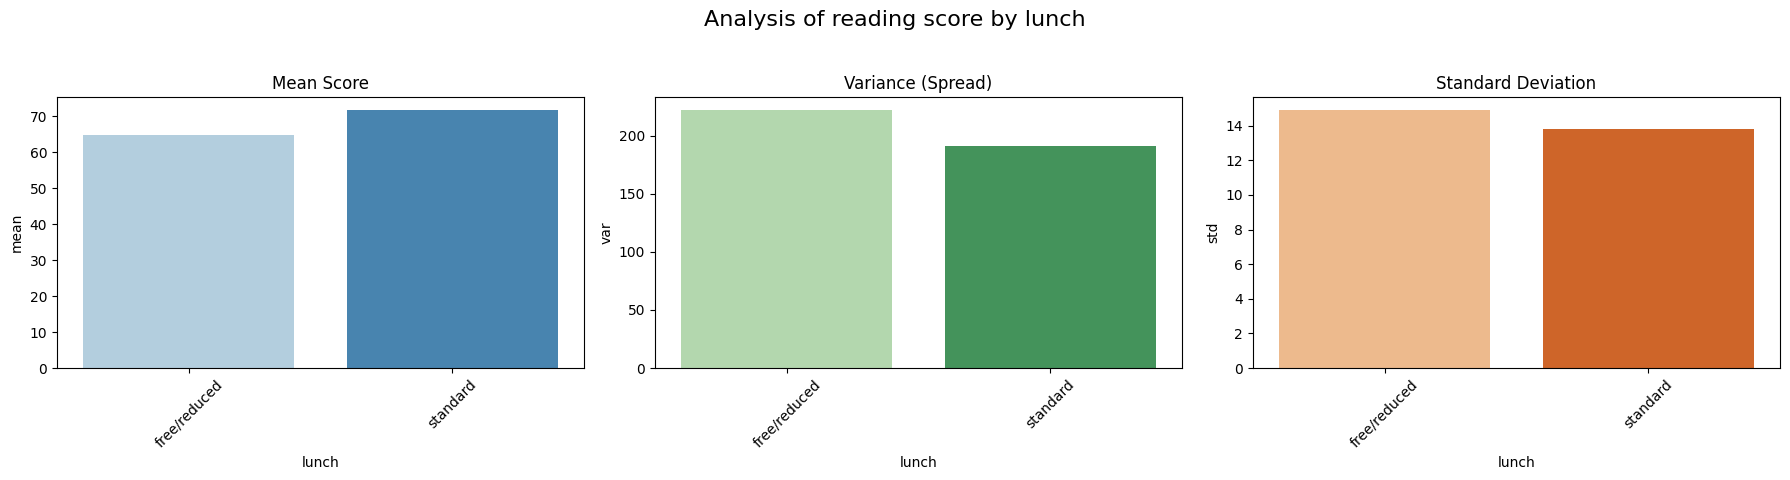

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


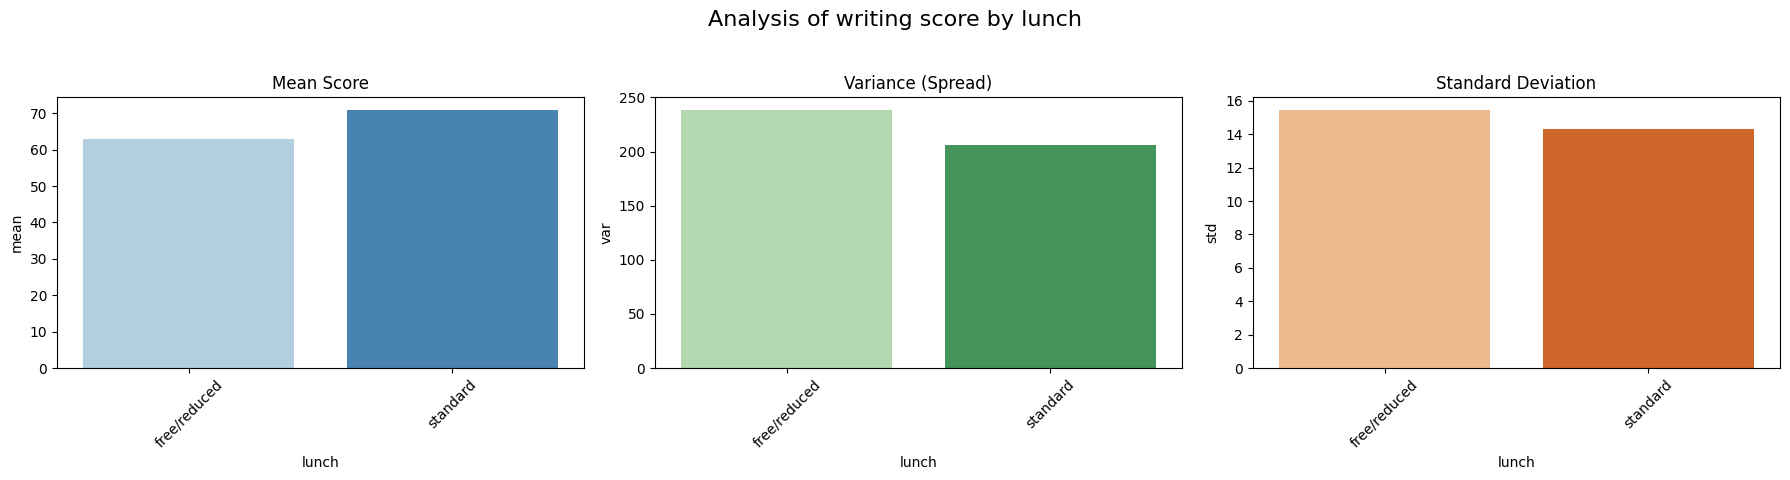

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


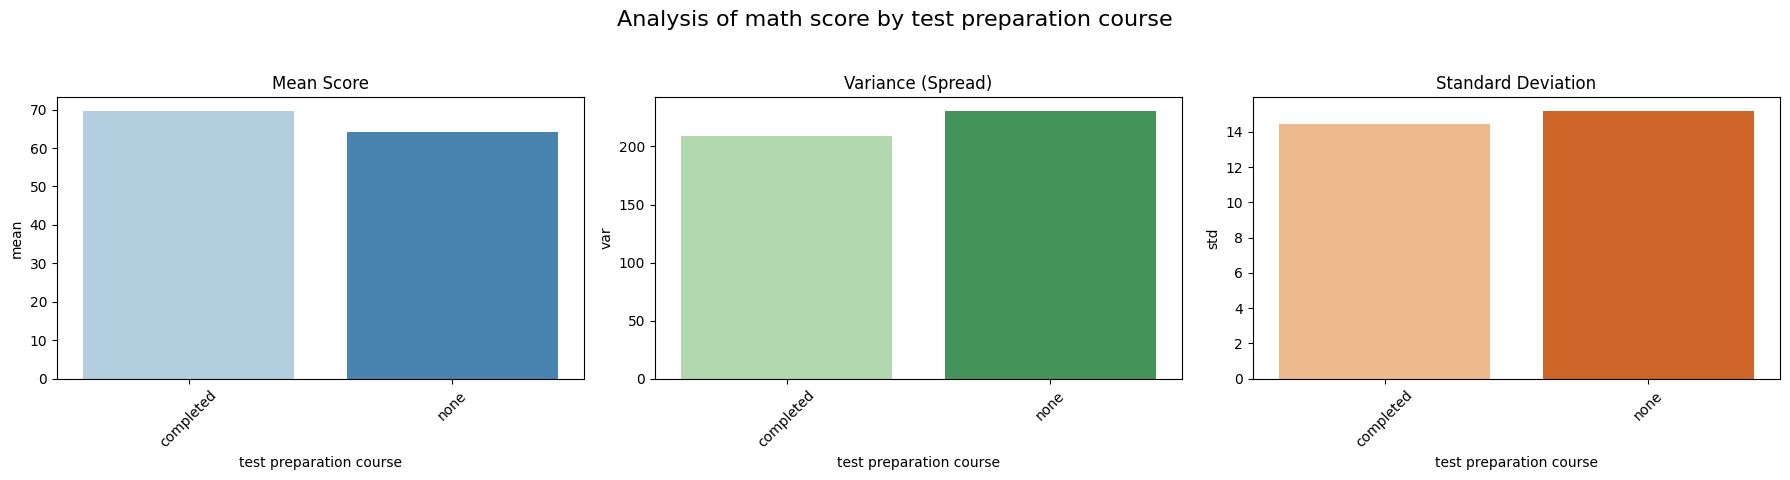

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


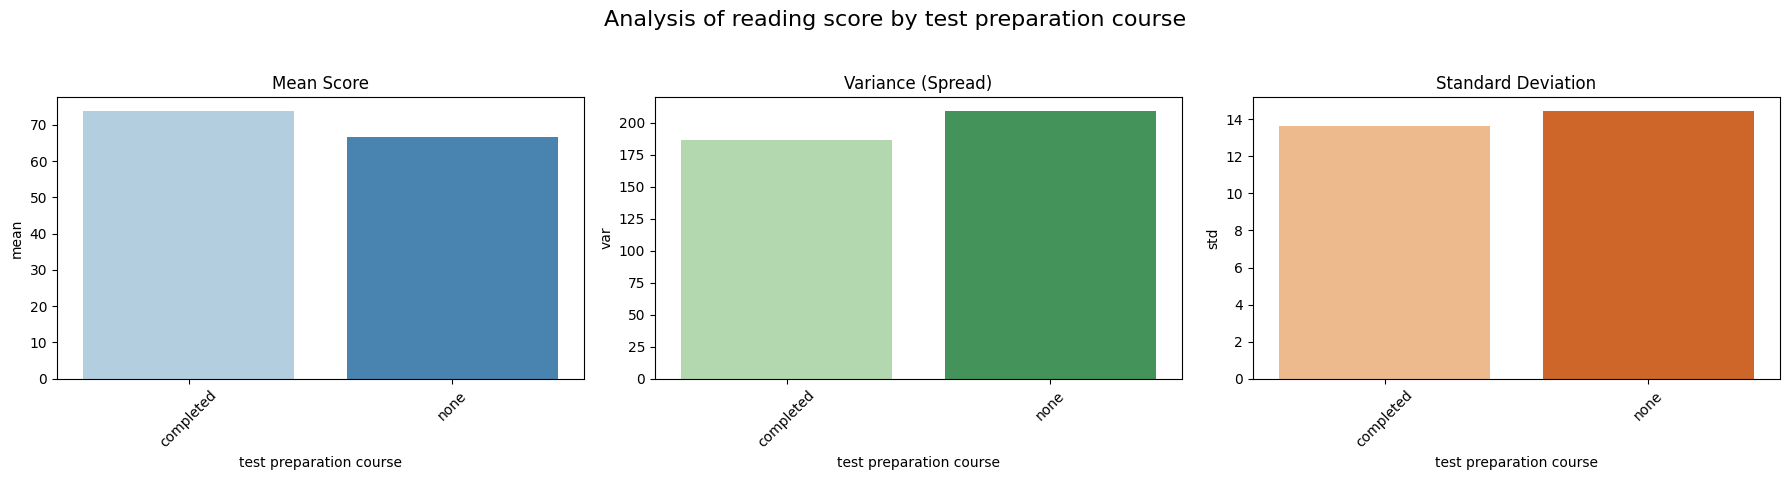

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1041994759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')


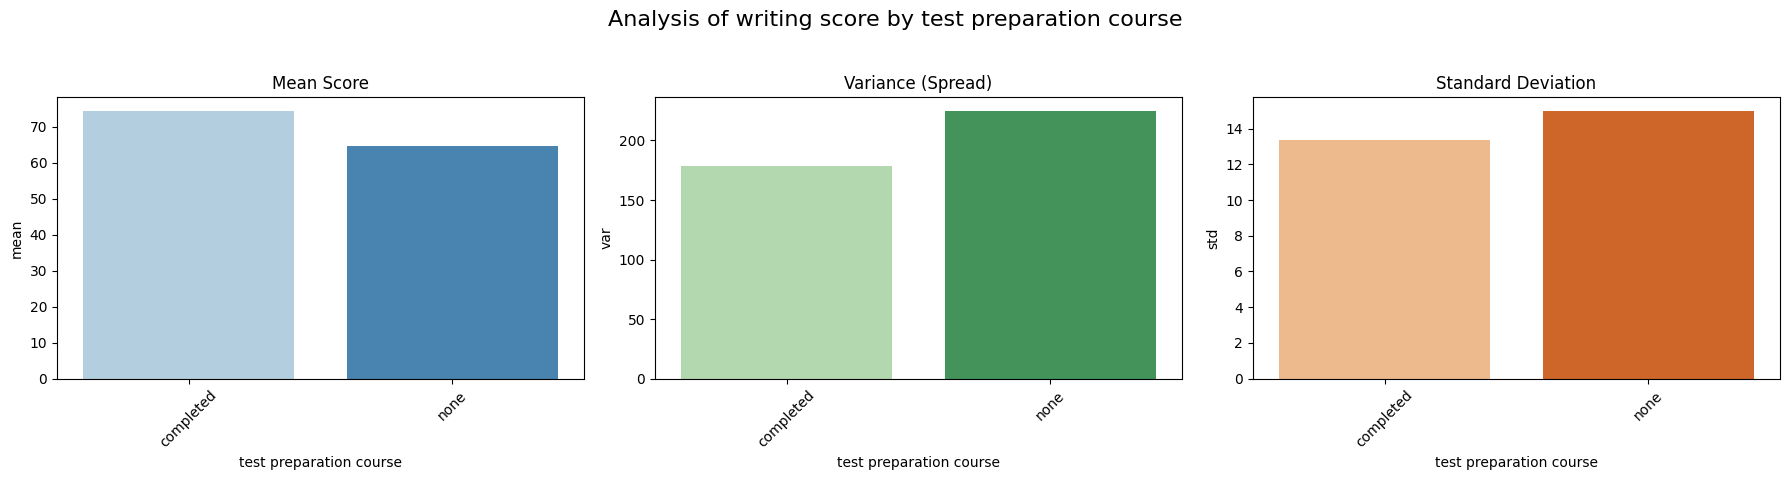

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

scores = ['math score', 'reading score', 'writing score']
columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for col in columns:
    for score in scores:
        # 1. Считаем статистики одной командой
        stats = dataset.groupby(col)[score].agg(['mean', 'var', 'std']).reset_index()
        
        # 2. Создаем сетку: 1 строка, 3 колонки
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Analysis of {score} by {col}', fontsize=16)

        # График 1: Mean (Среднее)
        sns.barplot(data=stats, x=col, y='mean', ax=axes[0], palette='Blues')
        axes[0].set_title('Mean Score')
        axes[0].tick_params(axis='x', rotation=45)

        # График 2: Variance (Дисперсия)
        sns.barplot(data=stats, x=col, y='var', ax=axes[1], palette='Greens')
        axes[1].set_title('Variance (Spread)')
        axes[1].tick_params(axis='x', rotation=45)

        # График 3: Std Deviation (Стандартное отклонение)
        sns.barplot(data=stats, x=col, y='std', ax=axes[2], palette='Oranges')
        axes[2].set_title('Standard Deviation')
        axes[2].tick_params(axis='x', rotation=45)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\415992220.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


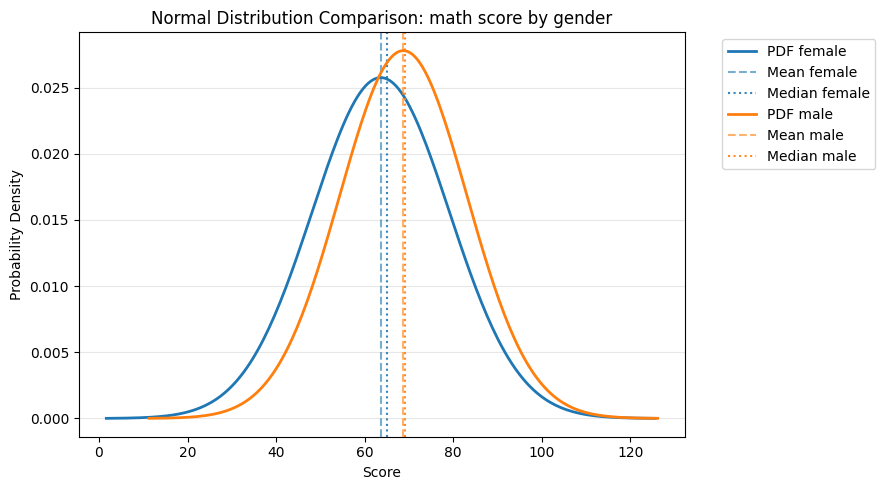

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\415992220.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


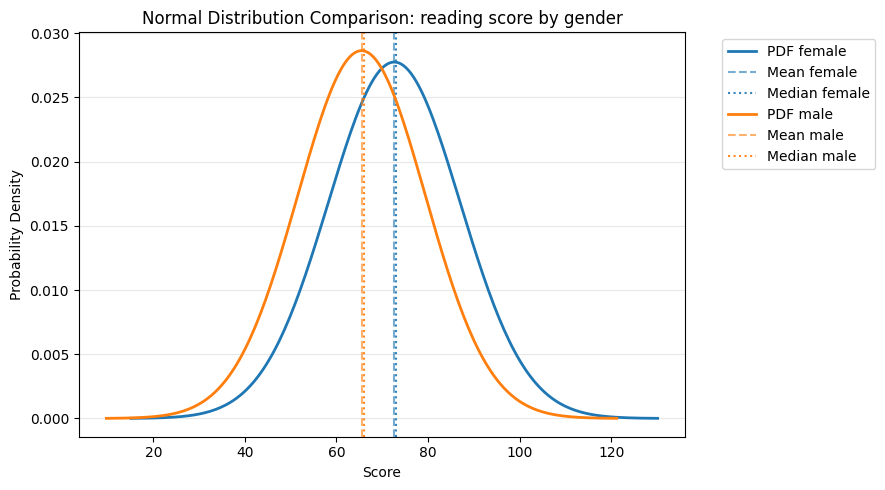

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\415992220.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


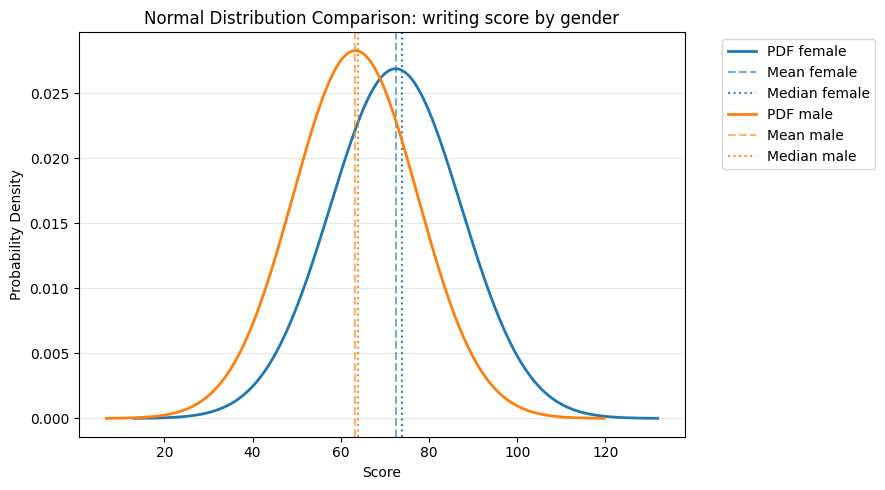

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\415992220.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


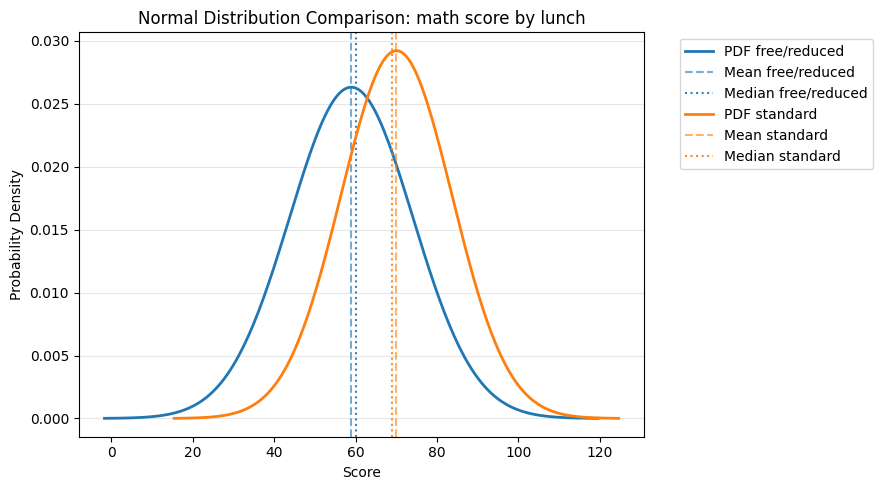

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\415992220.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


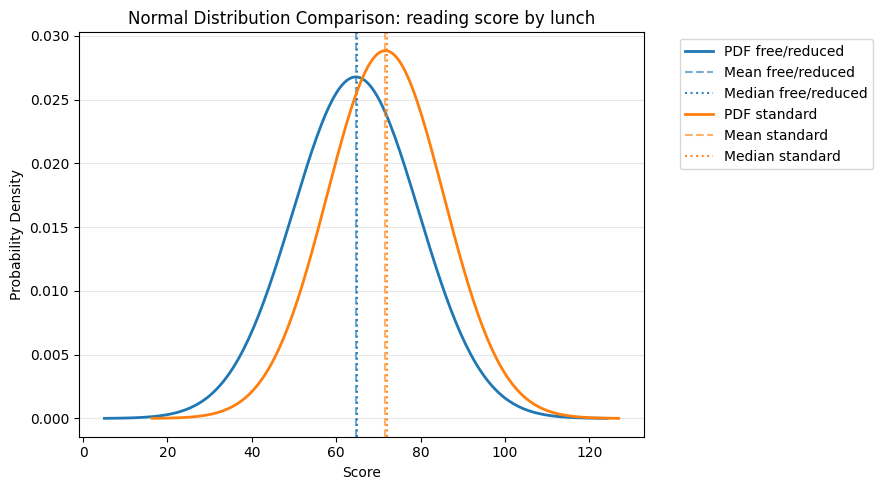

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\415992220.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


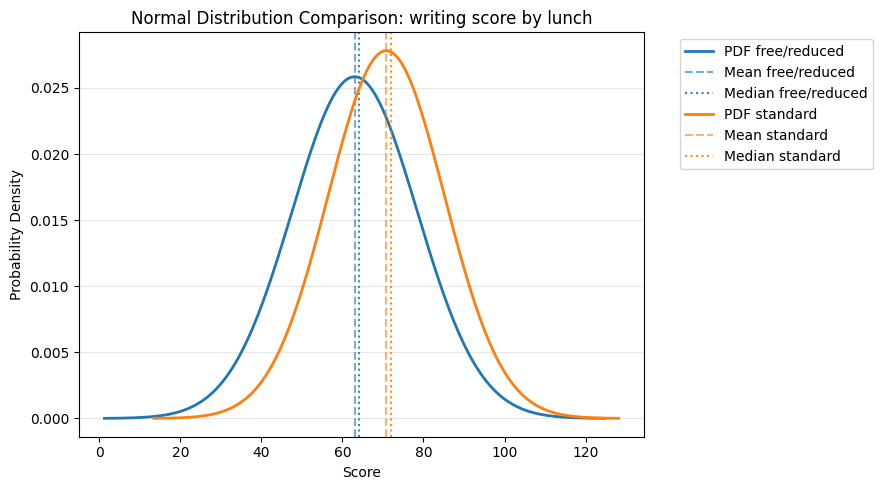

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\415992220.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


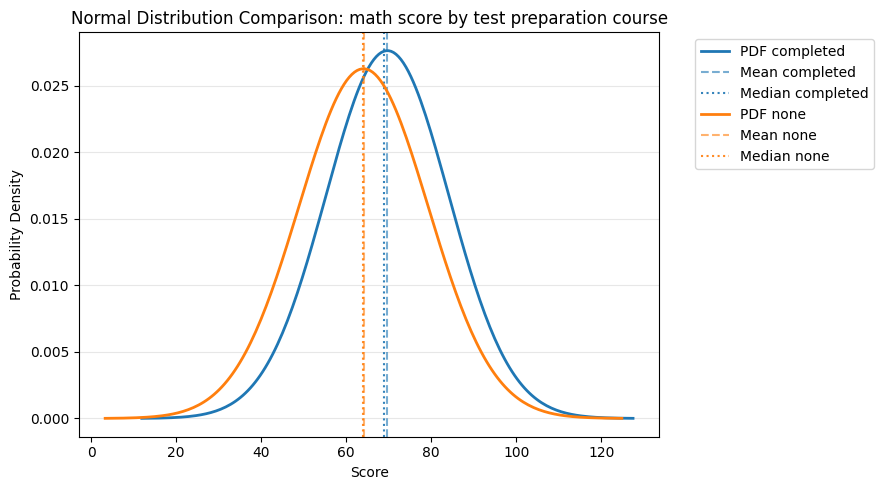

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\415992220.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


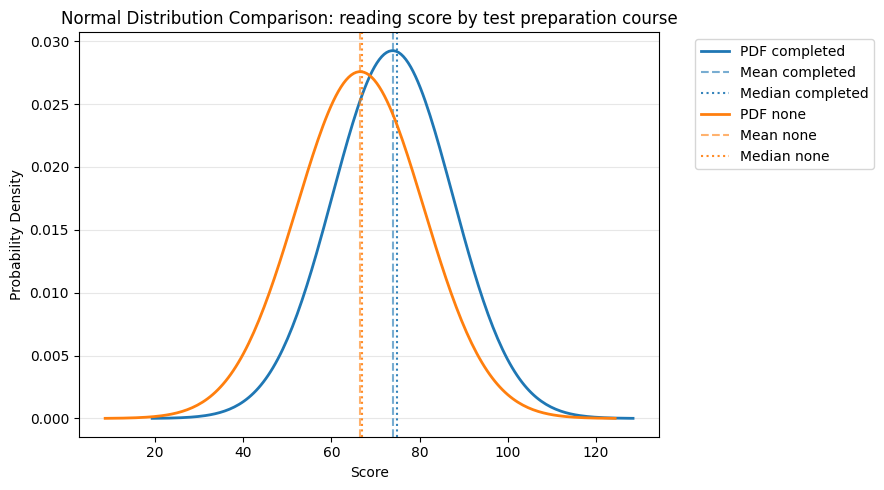

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\415992220.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


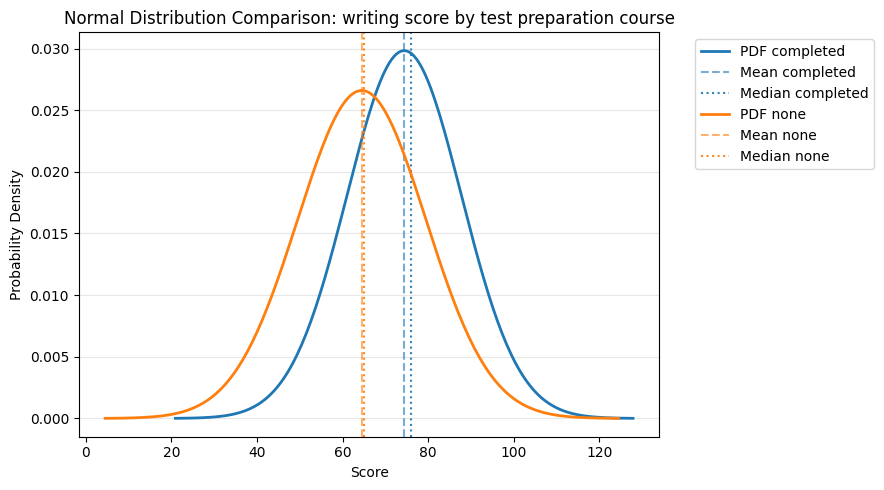

In [16]:
import numpy as np
import matplotlib.pyplot as plt

scores = ['math score', 'reading score', 'writing score']
columns = ['gender', 'lunch', 'test preparation course'] # пример колонок

for col in columns:
    for score in scores:
        # Группируем данные и считаем метрики для каждой категории (например, male/female)
        group_stats = dataset.groupby(col)[score].agg(['mean', 'median', 'std']).reset_index()
        
        plt.figure(figsize=(9, 5))
        
        # Генерируем разные цвета для разных категорий внутри одного признака
        colors = plt.cm.get_cmap('tab10', len(group_stats))
        
        for i, row in group_stats.iterrows():
            m = row['mean']
            md = row['median']
            s = row['std']
            label = row[col]
            
            # 1. Создаем ось X (диапазон 4 сигмы в обе стороны)
            x = np.linspace(m - 4*s, m + 4*s, 200)
            
            # 2. Считаем PDF (функцию плотности вероятности)
            y = (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m) / s) ** 2)
            
            # 3. Рисуем кривую
            line, = plt.plot(x, y, label=f"PDF {label}", linewidth=2)
            
            # 4. Добавляем линии среднего и медианы (пунктиром)
            plt.axvline(m, linestyle="--", color=line.get_color(), alpha=0.6, label=f"Mean {label}")
            plt.axvline(md, linestyle=":", color=line.get_color(), alpha=0.9, label=f"Median {label}")

        plt.title(f"Normal Distribution Comparison: {score} by {col}")
        plt.xlabel("Score")
        plt.ylabel("Probability Density")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Выносим легенду, чтобы не мешала
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1108904663.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


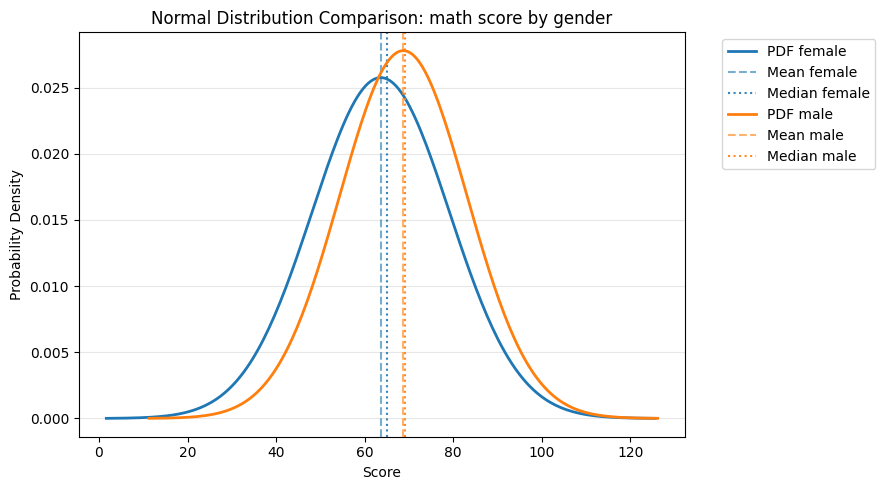

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1108904663.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


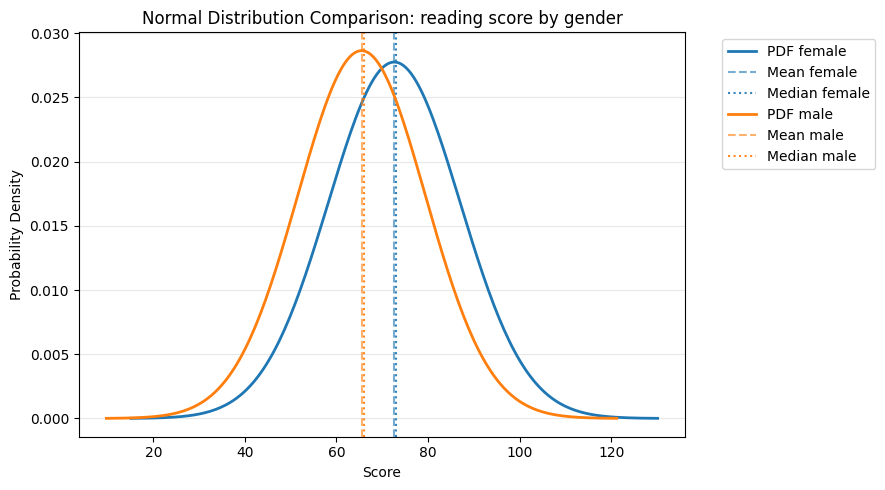

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1108904663.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


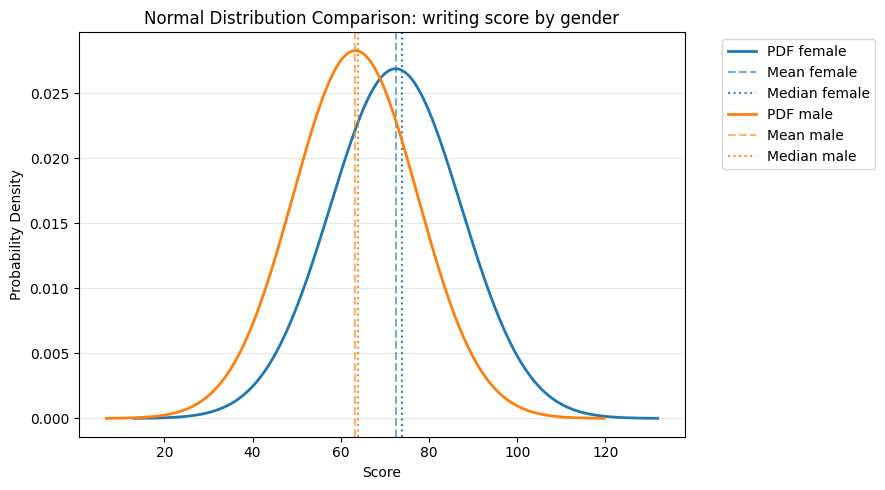

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1108904663.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


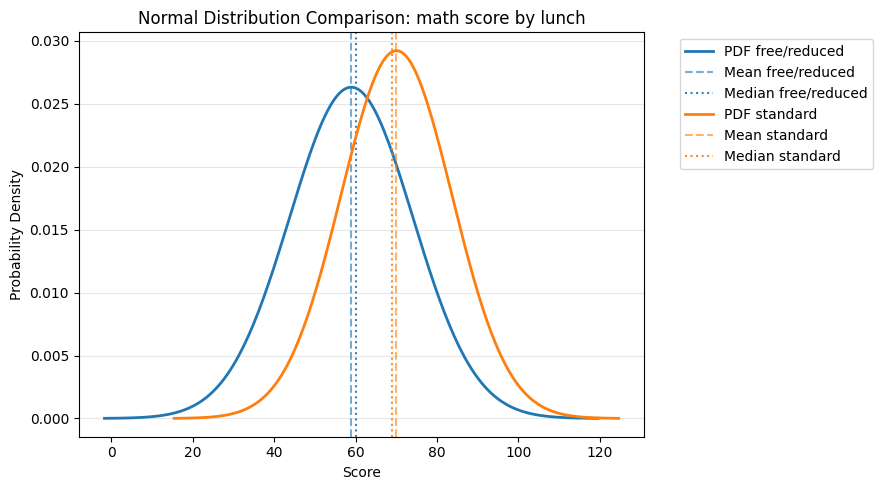

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1108904663.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


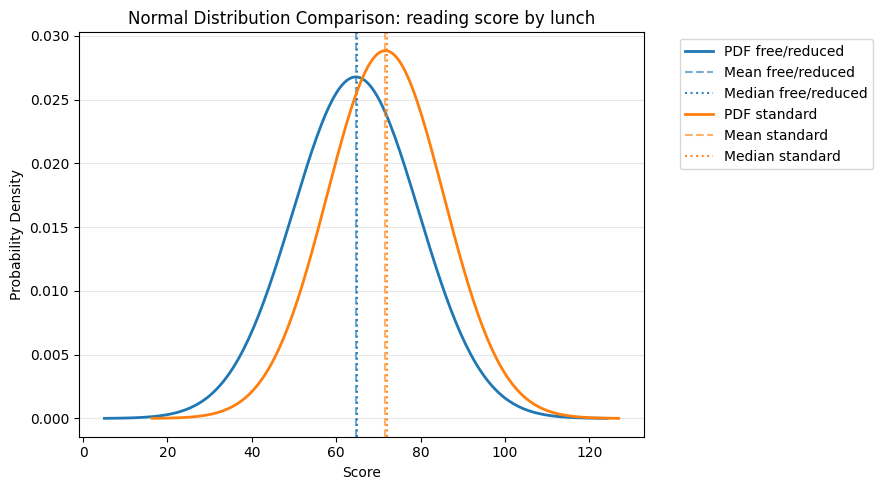

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1108904663.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


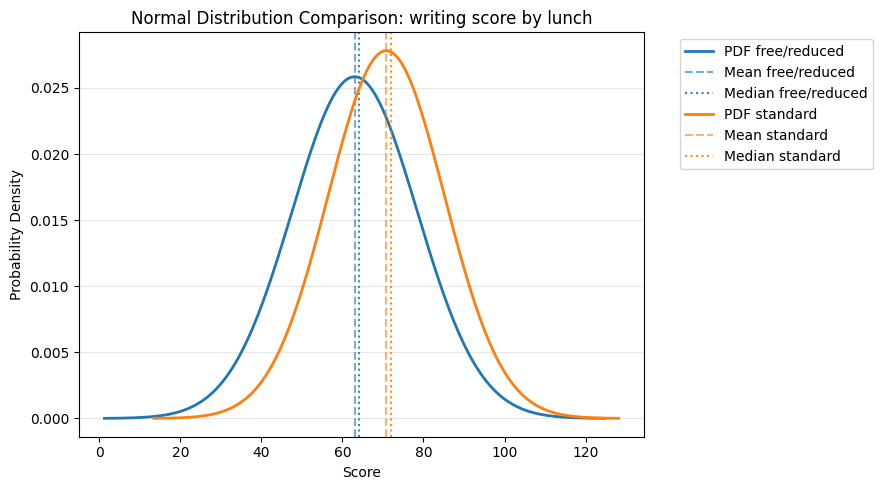

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1108904663.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


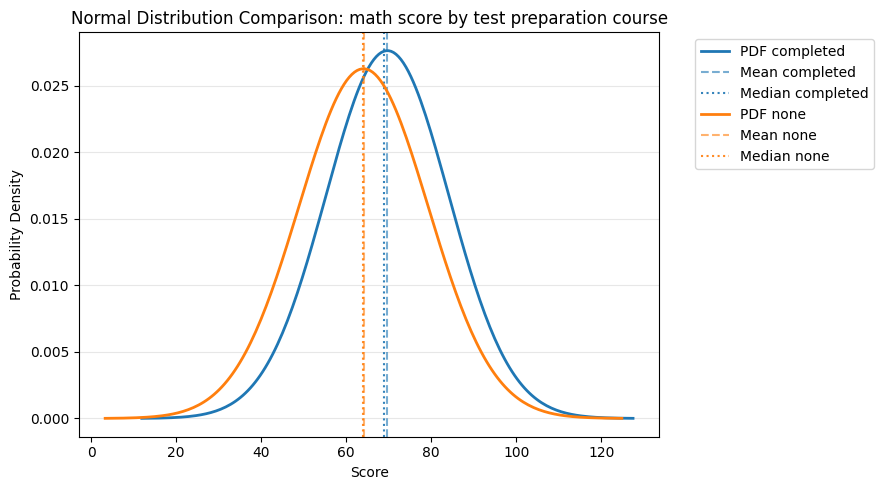

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1108904663.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


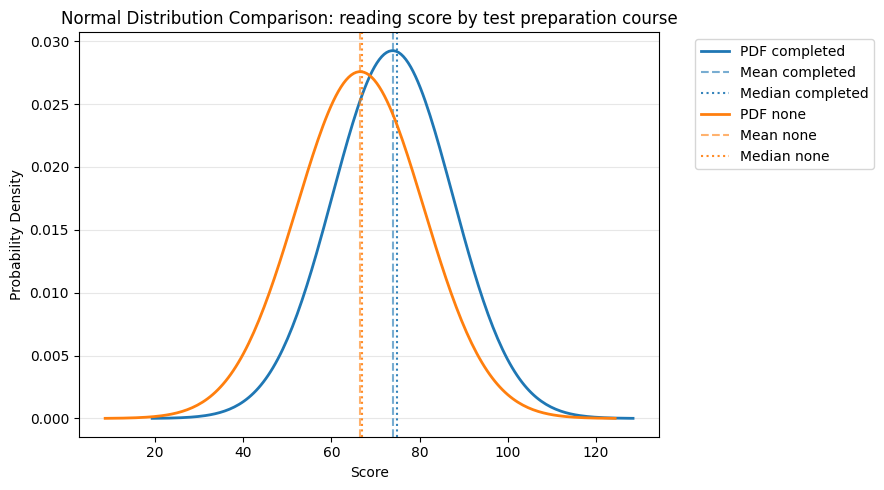

C:\Users\Legion\AppData\Local\Temp\ipykernel_23044\1108904663.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(group_stats))


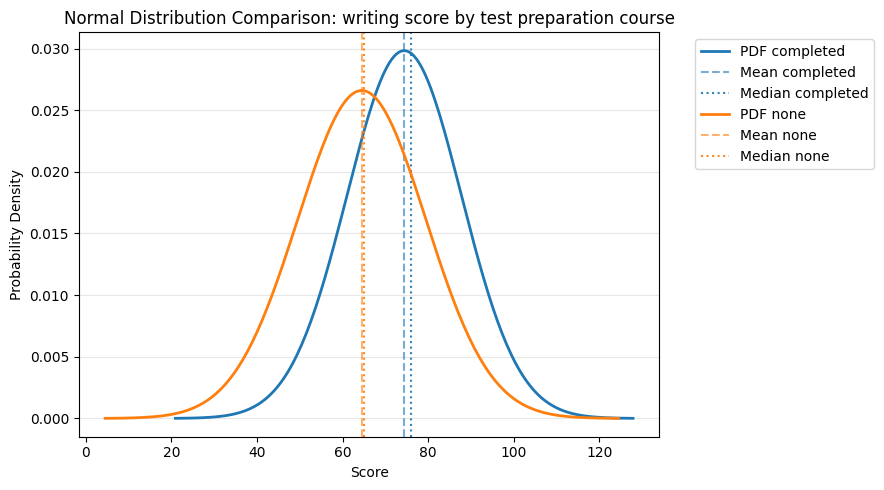

In [17]:
import numpy as np
import matplotlib.pyplot as plt

scores = ['math score', 'reading score', 'writing score']
columns = ['gender', 'lunch', 'test preparation course'] # пример колонок

for col in columns:
    for score in scores:
        group_stats = dataset.groupby(col)[score].agg(['mean', 'median', 'std']).reset_index()
        
        plt.figure(figsize=(9, 5))
        colors = plt.cm.get_cmap('tab10', len(group_stats))
        
        for i, row in group_stats.iterrows():
            m = row['mean']
            md = row['median']
            s = row['std']
            label = row[col]
            x = np.linspace(m - 4*s, m + 4*s, 200)
            y = (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m) / s) ** 2)
            line, = plt.plot(x, y, label=f"PDF {label}", linewidth=2)
            
            plt.axvline(m, linestyle="--", color=line.get_color(), alpha=0.6, label=f"Mean {label}")
            plt.axvline(md, linestyle=":", color=line.get_color(), alpha=0.9, label=f"Median {label}")
        plt.title(f"Normal Distribution Comparison: {score} by {col}")
        plt.xlabel("Score")
        plt.ylabel("Probability Density")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Выносим легенду, чтобы не мешала
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

In [18]:
import numpy as np
scores = ['math score', 'reading score', 'writing score']
for score in scores:
    group_stats = dataset.groupby('gender')[score].agg(['mean', 'var', 'count'])  
    m_mean, f_mean = group_stats.loc['male', 'mean'], group_stats.loc['female', 'mean']
    m_var, f_var   = group_stats.loc['male', 'var'], group_stats.loc['female', 'var']
    m_n, f_n       = group_stats.loc['male', 'count'], group_stats.loc['female', 'count']
    t_stat = (m_mean - f_mean) / np.sqrt((m_var / m_n) + (f_var / f_n))
    df = m_n + f_n - 2   
    print(f"Предмет: {score}")
    print(f"t-статистика (вручную): {t_stat:.4f}")
    print(f"Степени свободы: {df}")
    if abs(t_stat) > 1.96:
        print("Результат: Различия статистически значимы (|t| > 1.96)")
    else:
        print("Результат: Различия не значимы")
    print("-" * 30)

Предмет: math score
t-статистика (вручную): 5.3980
Степени свободы: 998
Результат: Различия статистически значимы (|t| > 1.96)
------------------------------
Предмет: reading score
t-статистика (вручную): -7.9684
Степени свободы: 998
Результат: Различия статистически значимы (|t| > 1.96)
------------------------------
Предмет: writing score
t-статистика (вручную): -9.9977
Степени свободы: 998
Результат: Различия статистически значимы (|t| > 1.96)
------------------------------


In [19]:
# Стандартизация данных 

In [20]:
import numpy as np
scores = ['math score', 'reading score', 'writing score']
for score in scores:
    group_stats = dataset.groupby('lunch')[score].agg(['mean', 'var', 'count'])  
    m_mean, f_mean = group_stats.loc['standard', 'mean'], group_stats.loc['free/reduced', 'mean']
    m_var, f_var   = group_stats.loc['standard', 'var'], group_stats.loc['free/reduced', 'var']
    m_n, f_n       = group_stats.loc['standard', 'count'], group_stats.loc['free/reduced', 'count']
    t_stat = (m_mean - f_mean) / np.sqrt((m_var / m_n) + (f_var / f_n))
    df = m_n + f_n - 2   
    print(f"Предмет: {score}")
    print(f"t-статистика (вручную): {t_stat:.4f}")
    print(f"Степени свободы: {df}")
    if abs(t_stat) > 1.96:
        print("Результат: Различия статистически значимы (|t| > 1.96)")
    else:
        print("Результат: Различия не значимы")
    print("-" * 30)

Предмет: math score
t-статистика (вручную): 11.4841
Степени свободы: 998
Результат: Различия статистически значимы (|t| > 1.96)
------------------------------
Предмет: reading score
t-статистика (вручную): 7.2926
Степени свободы: 998
Результат: Различия статистически значимы (|t| > 1.96)
------------------------------
Предмет: writing score
t-статистика (вручную): 7.8409
Степени свободы: 998
Результат: Различия статистически значимы (|t| > 1.96)
------------------------------


In [21]:
import numpy as np
scores = ['math score', 'reading score', 'writing score']
for score in scores:
    group_stats = dataset.groupby("test preparation course")[score].agg(['mean', 'var', 'count'])  
    m_mean, f_mean = group_stats.loc['none', 'mean'], group_stats.loc['completed', 'mean']
    m_var, f_var   = group_stats.loc['none', 'var'], group_stats.loc['completed', 'var']
    m_n, f_n       = group_stats.loc['none', 'count'], group_stats.loc['completed', 'count']
    t_stat = (m_mean - f_mean) / np.sqrt((m_var / m_n) + (f_var / f_n))
    df = m_n + f_n - 2   
    print(f"Предмет: {score}")
    print(f"t-статистика (вручную): {t_stat:.4f}")
    print(f"Степени свободы: {df}")
    if abs(t_stat) > 1.96:
        print("Результат: Различия статистически значимы (|t| > 1.96)")
    else:
        print("Результат: Различия не значимы")
    print("-" * 30)

Предмет: math score
t-статистика (вручную): -5.7870
Степени свободы: 998
Результат: Различия статистически значимы (|t| > 1.96)
------------------------------
Предмет: reading score
t-статистика (вручную): -8.0041
Степени свободы: 998
Результат: Различия статистически значимы (|t| > 1.96)
------------------------------
Предмет: writing score
t-статистика (вручную): -10.7525
Степени свободы: 998
Результат: Различия статистически значимы (|t| > 1.96)
------------------------------


In [27]:
from scipy.stats import f_oneway

cols = ['race/ethnicity', 'parental level of education']
scores = ['math score', 'reading score', 'writing score']

for column in cols:
    print(f"=== Анализ фактора: {column} ===")
    for score in scores:
        # Группируем данные только по ОДНОЙ текущей колонке и ОДНОМУ предмету
        groups = [group_data[score].values for name, group_data in dataset.groupby(column)]
        
        # Считаем ANOVA
        f_stat, p_val = f_oneway(*groups)
        
        print(f"Предмет: {score}")
        print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4e}")
        
        if p_val < 0.05:
            print(f"Результат: {column} ЗНАЧИМО влияет на {score}")
        else:
            print(f"Результат: Влияние {column} на {score} не доказано")
        print("-" * 10)
    print("\n")


=== Анализ фактора: race/ethnicity ===
Предмет: math score
F-statistic: 14.5939, p-value: 1.3732e-11
Результат: race/ethnicity ЗНАЧИМО влияет на math score
----------
Предмет: reading score
F-statistic: 5.6217, p-value: 1.7801e-04
Результат: race/ethnicity ЗНАЧИМО влияет на reading score
----------
Предмет: writing score
F-statistic: 7.1624, p-value: 1.0979e-05
Результат: race/ethnicity ЗНАЧИМО влияет на writing score
----------


=== Анализ фактора: parental level of education ===
Предмет: math score
F-statistic: 6.5216, p-value: 5.5923e-06
Результат: parental level of education ЗНАЧИМО влияет на math score
----------
Предмет: reading score
F-statistic: 9.2894, p-value: 1.1682e-08
Результат: parental level of education ЗНАЧИМО влияет на reading score
----------
Предмет: writing score
F-statistic: 14.4424, p-value: 1.1203e-13
Результат: parental level of education ЗНАЧИМО влияет на writing score
----------




In [30]:
import numpy as np
def bootstrap_ci(data, n_bootstrap=2000, ci=95):
    """Функция для расчета доверительного интервала через бутстрап"""
    boot_means = []
    n = len(data)
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))    
    lower_bound = np.percentile(boot_means, (100 - ci) / 2)
    upper_bound = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound
columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch' ,'test preparation course']
scores = ['math score']
for col in columns:
    print(f"=== 95% Bootstrap CI для {col} ===")
    unique_groups = dataset[col].unique()
    for score in scores:
        for group in unique_groups:
            group_data = dataset[dataset[col] == group][score].dropna().values
            
            low, high = bootstrap_ci(group_data)
            mean_val = np.mean(group_data)
            
            print(f"Группа {group}: Среднее = {mean_val:.2f}, CI = [{low:.2f}, {high:.2f}]")
    print("\n")

=== 95% Bootstrap CI для gender ===
Группа female: Среднее = 63.63, CI = [62.29, 64.96]
Группа male: Среднее = 68.73, CI = [67.44, 70.05]


=== 95% Bootstrap CI для race/ethnicity ===
Группа group B: Среднее = 63.45, CI = [61.19, 65.52]
Группа group C: Среднее = 64.46, CI = [62.84, 66.08]
Группа group A: Среднее = 61.63, CI = [58.57, 64.46]
Группа group D: Среднее = 67.36, CI = [65.67, 68.95]
Группа group E: Среднее = 73.82, CI = [71.29, 76.33]


=== 95% Bootstrap CI для parental level of education ===
Группа bachelor's degree: Среднее = 69.39, CI = [66.64, 71.85]
Группа some college: Среднее = 67.13, CI = [65.29, 69.08]
Группа master's degree: Среднее = 69.75, CI = [65.80, 73.46]
Группа associate's degree: Среднее = 67.88, CI = [65.89, 69.87]
Группа high school: Среднее = 62.14, CI = [60.17, 64.12]
Группа some high school: Среднее = 63.50, CI = [61.11, 65.80]


=== 95% Bootstrap CI для lunch ===
Группа standard: Среднее = 70.03, CI = [69.03, 71.09]
Группа free/reduced: Среднее = 58.92

In [31]:
import numpy as np
def bootstrap_ci(data, n_bootstrap=2000, ci=95):
    """Функция для расчета доверительного интервала через бутстрап"""
    boot_means = []
    n = len(data)
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))    
    lower_bound = np.percentile(boot_means, (100 - ci) / 2)
    upper_bound = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound
columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch' ,'test preparation course']
scores = ['reading score']
for col in columns:
    print(f"=== 95% Bootstrap CI для {col} ===")
    unique_groups = dataset[col].unique()
    for score in scores:
        for group in unique_groups:
            group_data = dataset[dataset[col] == group][score].dropna().values
            
            low, high = bootstrap_ci(group_data)
            mean_val = np.mean(group_data)
            
            print(f"Группа {group}: Среднее = {mean_val:.2f}, CI = [{low:.2f}, {high:.2f}]")
    print("\n")

=== 95% Bootstrap CI для gender ===
Группа female: Среднее = 72.61, CI = [71.34, 73.87]
Группа male: Среднее = 65.47, CI = [64.23, 66.74]


=== 95% Bootstrap CI для race/ethnicity ===
Группа group B: Среднее = 67.35, CI = [65.06, 69.58]
Группа group C: Среднее = 69.10, CI = [67.53, 70.65]
Группа group A: Среднее = 64.67, CI = [61.47, 67.97]
Группа group D: Среднее = 70.03, CI = [68.30, 71.71]
Группа group E: Среднее = 73.03, CI = [70.64, 75.57]


=== 95% Bootstrap CI для parental level of education ===
Группа bachelor's degree: Среднее = 73.00, CI = [70.38, 75.58]
Группа some college: Среднее = 69.46, CI = [67.66, 71.35]
Группа master's degree: Среднее = 75.37, CI = [71.73, 78.90]
Группа associate's degree: Среднее = 70.93, CI = [69.10, 72.71]
Группа high school: Среднее = 64.70, CI = [62.71, 66.57]
Группа some high school: Среднее = 66.94, CI = [64.57, 69.18]


=== 95% Bootstrap CI для lunch ===
Группа standard: Среднее = 71.65, CI = [70.63, 72.71]
Группа free/reduced: Среднее = 64.65

In [32]:
import numpy as np
def bootstrap_ci(data, n_bootstrap=2000, ci=95):
    """Функция для расчета доверительного интервала через бутстрап"""
    boot_means = []
    n = len(data)
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))    
    lower_bound = np.percentile(boot_means, (100 - ci) / 2)
    upper_bound = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound
columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch' ,'test preparation course']
scores = ['writing score']
for col in columns:
    print(f"=== 95% Bootstrap CI для {col} ===")
    unique_groups = dataset[col].unique()
    for score in scores:
        for group in unique_groups:
            group_data = dataset[dataset[col] == group][score].dropna().values
            
            low, high = bootstrap_ci(group_data)
            mean_val = np.mean(group_data)
            
            print(f"Группа {group}: Среднее = {mean_val:.2f}, CI = [{low:.2f}, {high:.2f}]")
    print("\n")

=== 95% Bootstrap CI для gender ===
Группа female: Среднее = 72.47, CI = [71.22, 73.76]
Группа male: Среднее = 63.31, CI = [62.09, 64.53]


=== 95% Bootstrap CI для race/ethnicity ===
Группа group B: Среднее = 65.60, CI = [63.46, 67.85]
Группа group C: Среднее = 67.83, CI = [66.20, 69.47]
Группа group A: Среднее = 62.67, CI = [59.51, 65.94]
Группа group D: Среднее = 70.15, CI = [68.44, 71.79]
Группа group E: Среднее = 71.41, CI = [68.81, 73.89]


=== 95% Bootstrap CI для parental level of education ===
Группа bachelor's degree: Среднее = 73.38, CI = [70.85, 75.96]
Группа some college: Среднее = 68.84, CI = [66.85, 70.74]
Группа master's degree: Среднее = 75.68, CI = [72.03, 79.14]
Группа associate's degree: Среднее = 69.90, CI = [68.00, 71.79]
Группа high school: Среднее = 62.45, CI = [60.41, 64.31]
Группа some high school: Среднее = 64.89, CI = [62.64, 67.12]


=== 95% Bootstrap CI для lunch ===
Группа standard: Среднее = 70.82, CI = [69.72, 71.91]
Группа free/reduced: Среднее = 63.02